#### DBSCAN(밀도 기반 군집화)

- 밀도 기반의 클러스터링 알고리즘으로 데이터의 밀도를 이용하여 군집을 생성 
- 데이터가 빽빽한(고밀도) 지역을 하나의 군집으로 생성을 하고 드문(저밀도) 지역은 노이즈(이상치)로 판단
- KMeans와는 다르게 군집의 개수를 지정할 필요 없다. 
- 비선형 구조의 데이터에서도 군집 형성이 가능 (원형, 나선형의 구조 데이터에서 패턴 분석 가능)
- 노이즈를 판단함으로 이상치에 대한 자동 감지 
- 스케일링은 일반적으로 사용(Standard, min-max)

- parameter
    - eps
        - 기본값 : 0.5
        - 두 개의 샘플이 같은 군집으로 간주되기 위한 최대의 거리 (반경)
        - 스케일링이 된 데이터를 기준으로 한다면 eps는 최대 2정도로 설정 
        - 스케일링이 되지 않는 데이터를 기준으로 한다면 eps 피쳐 안의 데이터의 범위에 따라 값이 변한다. 
    - min_samples
        - 기본값 : 5
        - 핵심점(core point)으로 판단하기 위한 샘플의 개수
    - metric
        - 기본값 : 'euclidean'
        - 거리 계산 방식
    - algorithm
        - 기본값 : 'auto'
        - 이웃 탐색 알고리즘
        - 'auto' -> 자동 선택. 데이터 특성에 따라 알고리즘 자동 선택
        - 'brute' -> 모든 점 간의 거리를 계산 -> 데이터의 개수가 적은 경우 사용(5000개 이하)
        - 'kd_tree' -> 저차원 데이터(20차원 이하)에서 매우 빠른 성능
        - 'ball_tree' -> 고차원 데이터에서 효율적인 거리 탐색(공간 분할 기반)
    - leaf_size
        - 기본값 : 30
        - Tree 알고리즘 사용하는 경우 리프의 크기를 지정 (미세한 성능을 조절할때 사용)
- 속성
    - core_sample_indices_
        - 핵심점의 인덱스의 목록
    - components_
        - 핵심점 좌표 배열
    - labels_
        - 각 데이터의 군집의 라벨 ( 노이즈는 -1로 표시 )
- 메서드
    - fit()
    - predict()

- 동작의 원리 
    1. 핵심점을 생성 ( 각 점에 대해서 이웃점의 개수를 계산 )
    2. 경계점을 생성 ( 핵심점 근처에 데이터가 존재하지만 자신이 핵심이 아닌 경우 )
    3. 노이즈점을 생성 ( 어떠한 군집에도 속하지 않은 데이터 )
    4. 핵심점에서 시작해서 이웃을 계속 측정하여 확장하면서 군집을 형성
- 파라미터 튜닝 팁
    - 너무 많은 노이즈가 생성이 된다?
        - eps 증가 시키거나 min_samples 감소
    - 군집이 너무 뭉치는 경우 
        - eps 감소
    - 너무 고차원인 경우 
        - 차원 축소를 통해서 고차원 데이터를 저차원으로 변경하고 사용
    - 속도가 너무 느리다
        - algorithm를 kd_tree로 변경하거나 n_jobs를 -1로 변경

In [48]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

In [49]:
df = pd.read_csv("../data/bodyPerformance.csv")

In [50]:
obj_cols = df.select_dtypes('object').columns
le = LabelEncoder()
for col in obj_cols:
    df[col] = le.fit_transform(df[col])

In [51]:
x = df.drop(['class'], axis=1)
y1 = df['class']
y2 = df['gender']

In [52]:
# 스케일링 
x_std = StandardScaler().fit_transform(x)

In [53]:
# x 데이터에서 k번째 최근접 이웃의 거리를 계산
# NearestNeighbors : 기존 데이터들 중에서 거리상 가장 가까운 k개의 이웃 데이터를 찾아 내는 역할
# n_neighbors 매개변수 -> 몇번째 이웃 데이터를 찾아낼것인가
nbrs = NearestNeighbors(n_neighbors=10).fit(x_std)
# kneighors() -> 특정 데이터와 가장 가까운 이웃들 같의 '거리'와 '위치(인덱스)'를 직접 계산해서 반환해주는 함수(핵심 기능)
distances, idxs = nbrs.kneighbors(x_std)

In [54]:
pd.DataFrame(distances)

,0,1,2,3,4,5,6,7,8,9
0,0.0,0.799130,0.809134,0.877655,0.887212,0.895526,0.958994,0.966260,0.975365,0.987738
1,0.0,0.952136,0.953805,0.979280,0.981214,1.000437,1.020492,1.039892,1.066270,1.096588
2,0.0,0.968743,1.018412,1.051686,1.068737,1.104132,1.140952,1.151689,1.161913,1.164665
3,0.0,0.699368,0.860201,0.877148,0.887239,0.924326,0.924853,0.944373,0.998661,0.999521
4,0.0,0.787191,0.850845,0.924892,1.001756,1.011084,1.038443,1.047140,1.069745,1.080112
...,...,...,...,...,...,...,...,...,...,...
13388,0.0,0.603419,0.925379,0.964653,0.976950,1.000742,1.022985,1.033451,1.033648,1.051184
13389,0.0,1.150575,1.367466,1.434887,1.437935,1.532010,1.538098,1.548787,1.550625,1.585287
13390,0.0,0.921356,0.983843,1.007682,1.153950,1.230502,1.239521,1.260068,1.283992,1.290565
13391,0.0,0.985813,1.291058,1.297391,1.426876,1.445313,1.500892,1.584475,1.587721,1.616496


In [55]:
# 각각의 거리 데이터에서 10번째 이웃의 거리만 추출
kth_list = np.sort(distances[ : , -1 ])

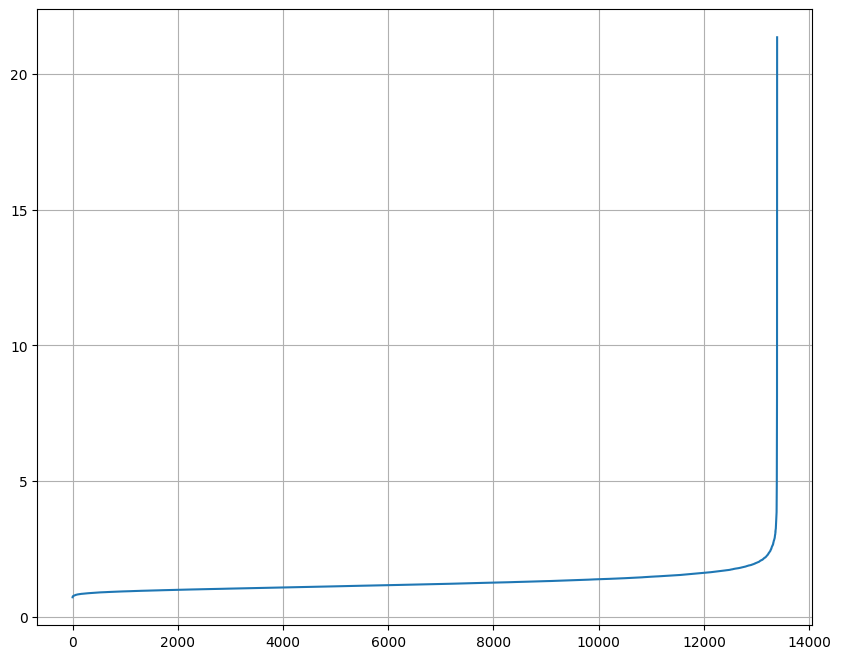

In [56]:
plt.figure(figsize=(10, 8))
plt.plot(kth_list)
plt.grid(True)
plt.show()

In [57]:
# eps -> 꺽이는 지점 (기울기 변화가 큰 지점을 eps)

diffs = np.diff(kth_list)
diffs

array([2.05561147e-02, 4.17030652e-03, 2.95242168e-03, ...,
       1.63507109e+00, 9.98022906e+00, 3.23074202e+00], shape=(13392,))

In [58]:
eps_ = np.where(diffs > 0.05)[0]

In [59]:
eps_

array([13357, 13370, 13371, 13374, 13376, 13378, 13380, 13382, 13383,
       13384, 13385, 13386, 13387, 13388, 13389, 13390, 13391])

In [60]:
print("급변하는 인덱스의 값 : ", eps_)
print('대략적인 eps의 최적의 값 : ', kth_list[eps_[0]])

급변하는 인덱스의 값 :  [13357 13370 13371 13374 13376 13378 13380 13382 13383 13384 13385 13386
 13387 13388 13389 13390 13391]
대략적인 eps의 최적의 값 :  3.051458810772378


In [66]:
# body data를 스케일링을 했을때 최적의 거리는 3으로 지정하면 군집이 깔끔하게 완성 -> 3???? -> 굉장히 큰 수치 
db = DBSCAN(
    eps = 1.7, 
    min_samples= 10, 
    n_jobs = -1
)

# 모델에 대한 학습 및 예측
labels = db.fit_predict(x_std)

In [67]:
set(labels)

{np.int64(-1), np.int64(0), np.int64(1)}

In [68]:
labels.shape

(13393,)

In [69]:
# 노이즈를 제외한 labels의 개수를 확인 
np.sum(labels == -1)

np.int64(341)

In [71]:
# 검증 지표
# 노이즈를 제외하고 검증 
flag = labels != -1
sil = silhouette_score( x_std[flag], labels[flag] )
ari = adjusted_rand_score(y1, labels)

print(sil)

print(ari)

0.3466129480317822
0.0049927528548928055


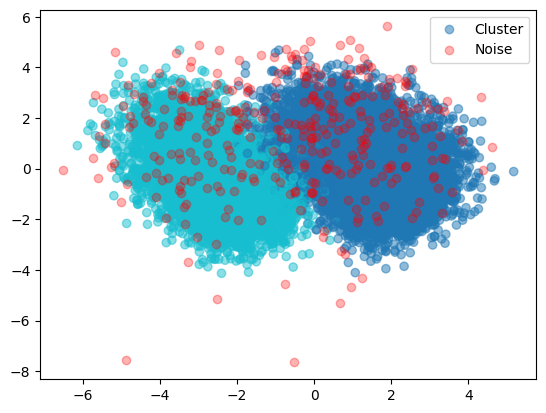

In [75]:
# PCA를 이용하여 2차원으로 차원 축소하고 그래프 시각화
pca = PCA(n_components=2, random_state=42)

x_pca = pca.fit_transform(x_std)

# 노이즈 / 비노이즈 부분을 다르게 표시 
non_noise = labels != -1

# 비노이즈 산점도 그래프 표시 
plt.scatter(x_pca[non_noise, 0], x_pca[non_noise, 1], c = labels[non_noise], cmap = 'tab10', label='Cluster', alpha=0.5)

# 노이즈 산점도 그래프 표시 
plt.scatter(x_pca[~non_noise, 0], x_pca[~non_noise, 1], c = 'red', label='Noise', alpha=0.3)

plt.legend()

plt.show()

In [76]:
# eps -> 반경 -> 줄였을때 노이즈의 개수가 실제로 변하는가?
db2 = DBSCAN(
    eps = 1.3, 
    min_samples= 10, 
    n_jobs = -1
)

labels2 = db2.fit_predict(x_std)

In [77]:
np.sum(labels2 == -1)

np.int64(1943)

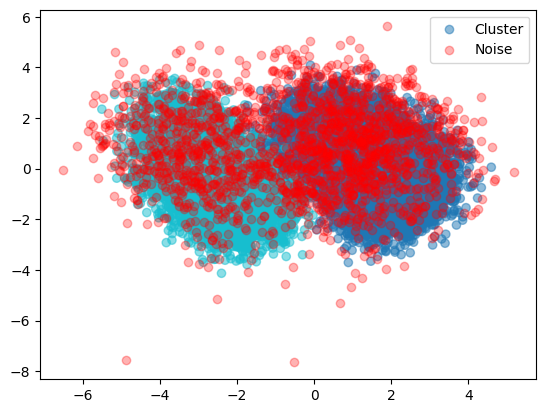

In [78]:
# 노이즈 / 비노이즈 부분을 다르게 표시 
non_noise = labels2 != -1

# 비노이즈 산점도 그래프 표시 
plt.scatter(x_pca[non_noise, 0], x_pca[non_noise, 1], c = labels[non_noise], cmap = 'tab10', label='Cluster', alpha=0.5)

# 노이즈 산점도 그래프 표시 
plt.scatter(x_pca[~non_noise, 0], x_pca[~non_noise, 1], c = 'red', label='Noise', alpha=0.3)

plt.legend()

plt.show()